# Binary Classification with a Small CNN and Grad-CAM

A from-scratch convolutional net on PneumoniaMNIST (28x28 grayscale), with the same
evaluation setup as the full-resolution chest study: val-AUC-based selection, early
stopping, a tuned decision threshold, and a Grad-CAM heatmap. Because the images are only
28x28 (center-cropped and normalized by MedMNIST), the localization is coarse, but the arc
mirrors chest [06](../chest-x-ray-images-pneumonia/06_mobilenetv2_transferring.ipynb).

## Setup

In [1]:
# One-time setup: make the `visualization` helper importable, then fetch data +
# resolve paths. Each study's fetch logic lives in its own download_data.py.
import os
import sys

if "google.colab" in sys.modules:
    if not os.path.isdir("ConvolutedComputerVision"):
        !git clone -q https://github.com/samlowe106/ConvolutedComputerVision.git
    sys.path.insert(0, "ConvolutedComputerVision/src")

from visualization import colab_bootstrap

DATA_ROOT, CKPT_ROOT = colab_bootstrap(study="pneumonia_mnist")

Mounted at /content/drive


  0%|                                              | 0.00/4.17M [00:00<?, ?B/s]

[colab_bootstrap] Colab run -> data='/content/drive/MyDrive/datasets/pneumonia-mnist', ckpt='/content/drive/MyDrive/cv-checkpoints'
[colab_bootstrap] WARNING: no GPU visible -- training will be very slow. Set Runtime > Change runtime type > GPU, then Runtime > Restart.


In [2]:
import datetime

import numpy as np
import tensorflow as tf
from sklearn.metrics import precision_recall_curve

notebook_start_time = datetime.datetime.now()

In [3]:
# load the MedMNIST PneumoniaMNIST .npz (fetched by download_data.py via the
# colab_bootstrap cell). Each split is (N, 28, 28) uint8 images + {0: normal, 1: pneumonia}.
_npz = np.load(os.path.join(DATA_ROOT, "pneumoniamnist.npz"))


def _make_ds(split):
    images = _npz[f"{split}_images"][..., None]  # add channel -> (N, 28, 28, 1)
    labels = _npz[f"{split}_labels"].reshape(-1).astype("int32")
    return tf.data.Dataset.from_tensor_slices((images, labels))


batch_size = 32
train_ds = _make_ds("train").batch(batch_size).prefetch(tf.data.AUTOTUNE)
validation_ds = _make_ds("val").batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = _make_ds("test").batch(batch_size).prefetch(tf.data.AUTOTUNE)

y_val = np.concatenate([y for _, y in validation_ds], axis=0)
y_test = np.concatenate([y for _, y in test_ds], axis=0)

In [4]:
from visualization import (
    class_weights,
    reset_keras,
    show_confusion_matrix,
    show_gradcam,
    summary_graphics,
)

class_weight = class_weights(train_ds, cache_dir=DATA_ROOT)
print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

Weight for normal class: 1.000
Weight for pneumonia class: 0.347


## Model

In [5]:
metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    tf.keras.metrics.AUC(name="auc"),
]


def make_callbacks(filepath):
    # select on val AUC (threshold-free, robust to the 74/26 class imbalance)
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=filepath, save_best_only=True, monitor="val_auc", mode="max"
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=6, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5, patience=3
        ),
    ]


epochs = 25

In [6]:
def build_cnn():
    # a small conv backbone with a GlobalAveragePooling head. No horizontal flip, since
    # chest anatomy is left/right specific. Rescaling lives inside the model so raw uint8
    # images (and Grad-CAM on raw images) work directly.
    return tf.keras.models.Sequential(
        [
            tf.keras.layers.Input((28, 28, 1), name="input"),
            tf.keras.layers.RandomRotation(0.1),
            tf.keras.layers.RandomZoom(0.1),
            tf.keras.layers.Rescaling(1.0 / 255),
            tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
            tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.SeparableConv2D(64, 3, padding="same", activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.SeparableConv2D(64, 3, padding="same", activation="relu"),
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
        ],
        name="pneumonia_mnist_cnn",
    )


reset_keras()
model = build_cnn()
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)
model.summary()

Model: "pneumonia_mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 14, 14, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 14, 14, 64)     │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,185 (82.75 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 31s 119ms/step - accuracy: 0.7821 - auc: 0.8235 - loss: 0.2689 - precision: 0.8619 - recall: 0.8412 - tn: 743.0000 - tp: 2939.0000 - val_accuracy: 0.2576 - val_auc: 0.9354 - val_loss: 0.9974 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 135.0000 - val_tp: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - accuracy: 0.8503 - auc: 0.9298 - loss: 0.1739 - precision: 0.9477 - recall: 0.8449 - tn: 1051.0000 - tp: 2952.0000 - val_accuracy: 0.5496 - val_auc: 0.9529 - val_loss: 0.6676 - val_precision: 1.0000 - val_recall: 0.3933 - val_tn: 135.0000 - val_tp: 153.0000 - learning_rate: 0.0010
Epoch 3/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.8738 - auc: 0.9461 - loss: 0.1513 - precision: 0.9597 - recall: 0.8663 - tn: 1087.0000 - tp: 3027.0000 - val_accuracy: 0.8912 - val_auc: 0.9582 - val_loss: 0.3123 - val_precision: 0.9256 - val_recall: 0.9280 - val_tn: 106.0000 - val_tp: 361.000

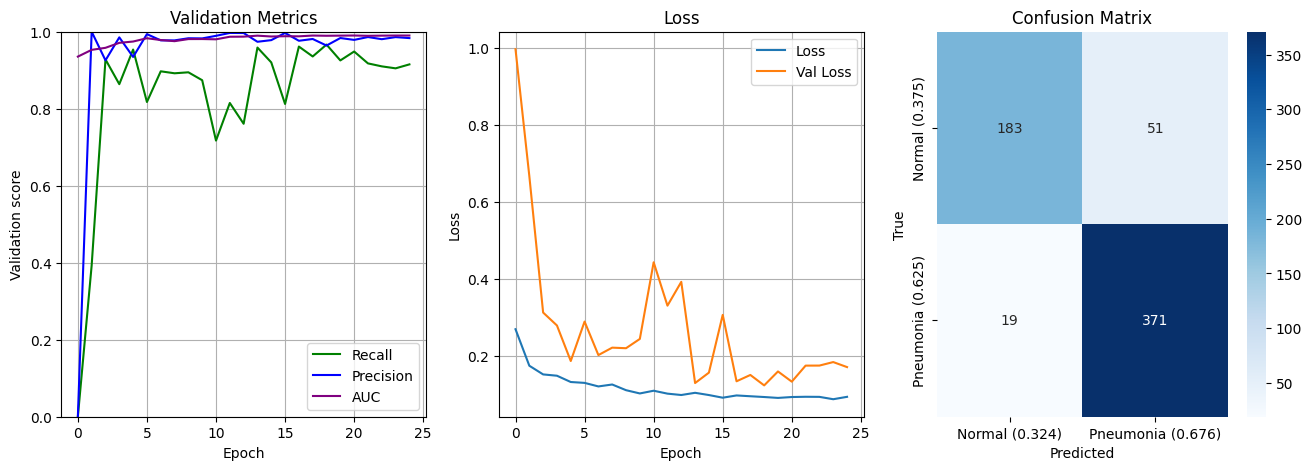

In [7]:
ckpt_path = os.path.join(CKPT_ROOT, "best_pneumonia_mnist_cnn.keras")
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks(ckpt_path),
)
best_model = tf.keras.models.load_model(ckpt_path)
summary_graphics(history, best_model, test_ds)

## Tuning the decision threshold

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Tuned threshold: 0.164  (default is 0.5)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
   default 0.5: accuracy=0.888  recall=0.951  precision=0.879  false negatives=19
   tuned 0.164: accuracy=0.832  recall=0.990  precision=0.793  false negatives=4


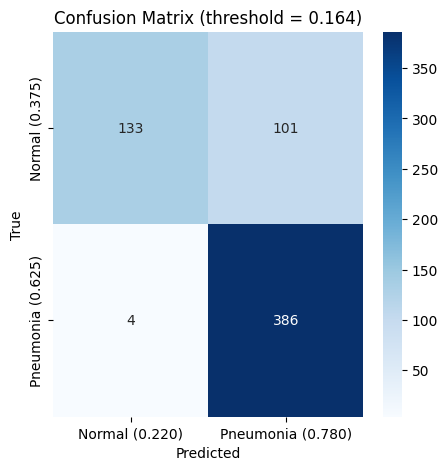

In [8]:
# Choose the decision threshold on the VALIDATION set (never on test), then apply it to
# test. A lower threshold trades a little precision for far fewer false negatives.
val_probs = best_model.predict(validation_ds).ravel()
precision, recall, thresholds = precision_recall_curve(y_val, val_probs)
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
threshold = float(thresholds[np.argmax(f1)])
print(f"Tuned threshold: {threshold:.3f}  (default is 0.5)\n")

test_probs = best_model.predict(test_ds).ravel()
for name, thr in [("default 0.5", 0.5), (f"tuned {threshold:.3f}", threshold)]:
    pred = (test_probs >= thr).astype("int32")
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    print(
        f"{name:>14}: accuracy={np.mean(pred == y_test):.3f}  "
        f"recall={tp / (tp + fn):.3f}  precision={tp / (tp + fp):.3f}  "
        f"false negatives={fn}"
    )

show_confusion_matrix(
    y_test,
    (test_probs >= threshold).astype("int32"),
    title=f"Confusion Matrix (threshold = {threshold:.3f})",
)

## Grad-CAM: where is the model looking?

Grad-CAM weights the last convolutional feature map by the gradient of the pneumonia score,
showing which regions drove the prediction. On the most confident pneumonia case a healthy
model should favor the lung region over the image borders.

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


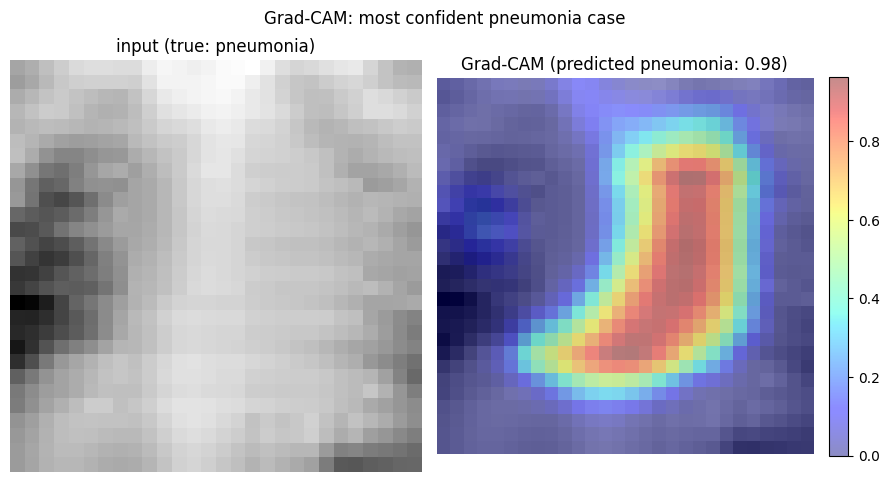

np.float32(0.9782324)

In [9]:
# Grad-CAM on the model's most confident PNEUMONIA case. At 28x28 the localization is
# coarse, but a healthy model should still favor the lung region over the borders.
scores = best_model.predict(test_ds).ravel()
pos_i = max((i for i in range(len(y_test)) if y_test[i] == 1), key=lambda i: scores[i])
all_images = np.concatenate([bx.numpy() for bx, _ in test_ds], axis=0)

show_gradcam(
    all_images[pos_i],
    best_model,
    class_name="pneumonia",
    true_label="pneumonia",
    title="Grad-CAM: most confident pneumonia case",
)

In [10]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} "
    f"(duration: {notebook_end_time - notebook_start_time})"
)

Notebook last run (end-to-end): 2026-07-13 05:19:19.111776 (duration: 0:07:34.876474)
